In [3]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Euclidean distance

In [4]:
import networkx as nx

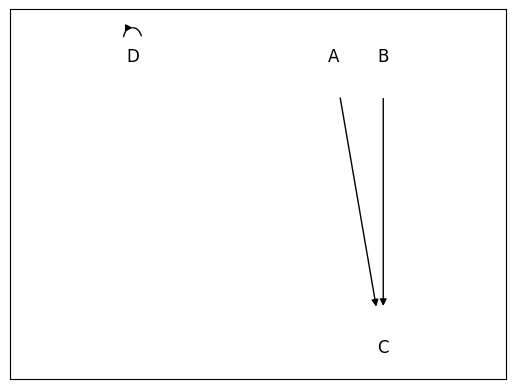

In [118]:
# create a directed graph
# https://medium.com/@whystudying/causal-inference-with-python-causal-graphs-ef2f3a52c266
plt.margins(x = 0.4)

G = nx.DiGraph()

# add edges from a list of tuples
G.add_edges_from([('A', 'B'),\
                  ('B', 'C'),\
                  ('A', 'C'), ('D', 'D')
                 ])
                  #('social_media_usage', 'creativity')])

# fix the positions of all three nodes
fixed_positions = {'A':(0.8,1),\
                   'B':(1,1), \
                   'C':(1,0), 'D':(0,1)}

# draw the network
nx.draw_networkx(G,\
                 with_labels = True,\
                 node_color = 'white',\
                 node_size = 1000,\
                 pos = fixed_positions, min_source_margin = 30, min_target_margin = 30)

In [ ]:
doc1 = 'happy' * 10, 'birthday' * 20
doc2 = 'happy' * 5, 'birthday' * 10
np.sqrt((10 - 5)**2 + (20 - 10)**2)

In [138]:
arr1 = np.array([10, 20])
arr2 = np.array([5, 10])

def euclidean_distance(arr1, arr2):
    total = 0
    for n in range(arr1.shape[0]):
        total += (arr1[n] - arr2[n])**2
    return np.sqrt(total)

def manhattan_distance(arr1, arr2):
    total = 0
    for x, y in zip(arr1, arr2):
        total += np.abs(x - y)
    return total

def minkowski_distance(arr1, arr2, p):
    total = 0
    for x, y in zip(arr1, arr2):
        total += np.abs(x - y)**p
    return total**(1/p)

def cosine_similarity(arr1, arr2):
    return arr1.dot(arr2) / np.linalg.norm(arr1) / np.linalg.norm(arr2)

def cosine_distance(arr1, arr2):
    return 1 - cosine_similarity(arr1, arr2)

cosine_similarity(arr1, arr2)
cosine_distance(arr1, arr2)

1.1102230246251565e-16

In [39]:
#plt.plot([0, 1], [0, 2])
#plt.plot([0, 2], [0, -1])
#ax = plt.gca()
#ax.set_aspect('equal', adjustable='datalim')
#ax.autoscale_view()
#plt.show()

In [43]:
arr1 = np.array([1, 2])
arr2 = np.array([100, 200])

def euclidean_distance(arr1, arr2):
    total = 0
    for x, y in zip(arr1, arr2):
        total += (x - y)**2
    return np.sqrt(total)

def manhattan_distance(arr1, arr2):
    total = 0
    for x, y in zip(arr1, arr2):
        total += np.abs(x - y)
    return total

def minkowski_distance(arr1, arr2, p):
    total = 0
    for x, y in zip(arr1, arr2):
        total += np.abs(x - y)**p
    return total**(1/p)

def cosine_similarity(arr1, arr2):
    return arr1.dot(arr2) / (np.linalg.norm(arr1) * np.linalg.norm(arr2))

def cosine_distance(arr1, arr2):
    return 1 - cosine_similarity(arr1, arr2)

print(cosine_distance(arr1, arr2))

0.0


In [189]:
# X = did patient get a drug treatment?  0 = no, 1 = yes
# Y = how much improvement in patient
# Z1 = age (Z score)
# Z2 = height (Z score)
# Z score: (variable - mean) / (standard deviation), has mean 0 and stddev 1
# Goal: Find coefficient of X
num = 100000
np.random.seed(0)
Z1 = np.random.normal(0, 1, num) # Z score for age
Z2 = np.random.normal(0, 1, num) # Z score for height
X = np.random.binomial(1, 1 / (1 + np.exp(Z1 + Z2 + Z1 * Z2 + np.random.normal(0, 1, num))))
Y = X + 2 * Z1 - Z2 + X * Z1 + np.random.normal(0, 1, num)
df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})

In [190]:
results = sm.OLS(Y, sm.add_constant(df[["X", "Z1", "Z2"]])).fit()
results.params

const   -0.120211
X        0.955188
Z1       2.531904
Z2      -1.120797
dtype: float64

In [191]:
treated.shape

(51949, 4)

In [192]:
treated = df[df.X == 1]
untreated = df[df.X == 0]

neighbors = NearestNeighbors(n_neighbors = 1)
neighbors.fit(untreated[["Z1", "Z2"]])
distances, indices = neighbors.kneighbors(treated[["Z1", "Z2"]])
treated.Y.mean() - untreated.iloc[indices.ravel()].Y.mean()

0.7179040741229261

In [193]:
treated.Y.mean() - untreated.Y.mean()

0.10544550647595546

In [199]:
num = 100000
np.random.seed(0)
Z1 = np.random.normal(0, 1, num)
Z2 = np.random.normal(0, 1, num)
X = np.random.binomial(1, 1 / (1 + np.exp(Z1 + Z2 + Z1 * Z2 + np.random.normal(0, 1, num))))
Y = X + 2 * Z1 - Z2 + X * Z1 + np.random.normal(0, 1, num)
df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})

In [200]:
treated = df[df.X == 1]
untreated = df[df.X == 0]

treated_neighbors = NearestNeighbors(n_neighbors=1)
treated_neighbors.fit(treated[["Z1", "Z2"]])
untreated_neighbors = NearestNeighbors(n_neighbors=1)
untreated_neighbors.fit(untreated[["Z1", "Z2"]])

NearestNeighbors(n_neighbors=1)

In [201]:
distances_treated_cf, indices_treated_cf = untreated_neighbors.kneighbors(treated[["Z1", "Z2"]])
distances_untreated_cf, indices_untreated_cf = treated_neighbors.kneighbors(untreated[["Z1", "Z2"]])

In [202]:
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

0.7179040741229261
1.290803748789105
0.10544550647595546


In [203]:
att = treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean()
atut = treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean()
ate = (att * treated.shape[0] + atut * untreated.shape[0]) / df.shape[0]
att, atut, ate

(0.7179040741229261, 1.290803748789105, 0.9931880967967719)

# Manhattan, Euclidean, and Cosine distances

In [104]:
def make_neighbors(num, coef1, coef2, metric):
    np.random.seed(0)
    Z1 = np.random.normal(0, 1, num)
    Z2 = np.random.normal(0, 1, num)
    X = np.random.binomial(1, 1 / (1 + np.exp(Z1 + Z2 + Z1 * Z2 + np.random.normal(0, 1, num))))
    Y = X + coef1 * Z1 + coef2 * Z2 + np.random.normal(0, 1, num)
    df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})
    treated = df[df.X == 1]
    untreated = df[df.X == 0]

    treated_neighbors = NearestNeighbors(n_neighbors=1, metric=metric)
    treated_neighbors.fit(treated[["Z1", "Z2"]])
    untreated_neighbors = NearestNeighbors(n_neighbors=1, metric= metric)
    untreated_neighbors.fit(untreated[["Z1", "Z2"]])
    distances_treated_cf, indices_treated_cf = untreated_neighbors.kneighbors(treated[["Z1", "Z2"]])
    distances_untreated_cf, indices_untreated_cf = treated_neighbors.kneighbors(untreated[["Z1", "Z2"]])
    return treated, untreated, indices_treated_cf, indices_untreated_cf

In [208]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(100000, 1, 1, "manhattan")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

0.998981259681682
0.986305328665508
-0.17090670230302502


In [110]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(100000, 1, 1, "euclidean")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

1.0004734057612772
0.9839794200861797
-0.17090670230302502


In [172]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(100000, 1, 10, "euclidean")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

0.998575096431215
0.9352407652411165
-5.335846099608399


In [209]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(10000, 1, 1, "cosine")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

0.840986036026156
0.6902276103983104
-0.12046683526307445


In [171]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(10000, 1, 1, "euclidean")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

1.0574960076885727
0.9686104630424105
-0.12046683526307445


In [ ]:
#(Z1 = 4 / Z2 = 2), (Z1 = 6 / Z2 = 3)

In [210]:
def make_neighbors2(num, coef1, metric):
    np.random.seed(0)
    Z1 = np.random.normal(0, 1, num)
    Z2 = np.random.normal(0, 1, num)
    X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))
    Y = X + coef1 * 1 / (1 + np.exp(np.abs(Z1 / Z2))) + np.random.normal(0, 1, num)
    df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})
    treated = df[df.X == 1]
    untreated = df[df.X == 0]

    treated_neighbors = NearestNeighbors(n_neighbors=1, metric=metric)
    treated_neighbors.fit(treated[["Z1", "Z2"]])
    untreated_neighbors = NearestNeighbors(n_neighbors=1, metric= metric)
    untreated_neighbors.fit(untreated[["Z1", "Z2"]])
    distances_treated_cf, indices_treated_cf = untreated_neighbors.kneighbors(treated[["Z1", "Z2"]])
    distances_untreated_cf, indices_untreated_cf = treated_neighbors.kneighbors(untreated[["Z1", "Z2"]])
    return treated, untreated, indices_treated_cf, indices_untreated_cf

In [176]:
a.Z1.mean()

0.010832674778789

In [177]:
a = treated.iloc[indices_untreated_cf.ravel()].reset_index()
b = untreated.reset_index()
(a.Y - a.X - 1 / (1 + np.exp(np.abs(a.Z1 / a.Z2)))).mean()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


1.1899409035364037

In [211]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors2(10000, 1, "cosine")
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_39387/1034710152.py:5: RuntimeWarning: overflow encountered in exp
  X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))
/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_39387/1034710152.py:6: RuntimeWarning: overflow encountered in exp
  Y = X + coef1 * 1 / (1 + np.exp(np.abs(Z1 / Z2))) + np.random.normal(0, 1, num)


0.9785809356529942
0.9302892578335327
1.0032178781500742


In [70]:
treated, untreated, indices_treated_cf, indices_untreated_cf = make_neighbors(100000, 1, 1, "manhattan")

In [71]:
print(treated.Y.mean() - untreated.iloc[indices_treated_cf.ravel()].Y.mean())
print(treated.iloc[indices_untreated_cf.ravel()].Y.mean() - untreated.Y.mean())
print(treated.Y.mean() - untreated.Y.mean())

0.998981259681682
0.986305328665508
-0.17090670230302502


# Gradient Boost

In [212]:
num = 10000
np.random.seed(0)
Z1 = np.random.normal(0, 1, num)
Z2 = np.random.normal(0, 1, num)
X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))
Y = X + 2 * Z1 - Z2 + np.random.normal(0, 1, num)
df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_39387/3589688251.py:5: RuntimeWarning: overflow encountered in exp
  X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))


In [213]:
def test_three(df, Y):
    X_train, X_test, y_train, y_test = train_test_split(df.values, Y)
    gbr = GradientBoostingRegressor().fit(X_train, y_train)
    print("Gradient Boost RMS:", root_mean_squared_error(gbr.predict(X_test), y_test))
    rfr = RandomForestRegressor().fit(X_train, y_train)
    print("Random Forest RMS:", root_mean_squared_error(rfr.predict(X_test), y_test))
    lr = LinearRegression().fit(X_train, y_train)
    print("Linear Regression RMS:", root_mean_squared_error(lr.predict(X_test), y_test))

In [45]:
def test_three(df, Y):
    X_train, X_test, y_train, y_test = train_test_split(df.values, Y)
    gbr = GradientBoostingRegressor().fit(X_train, y_train)
    print("Gradient Boost RMS:", root_mean_squared_error(gbr.predict(X_test), y_test))
    rfr = RandomForestRegressor().fit(X_train, y_train)
    print("Random Forest RMS:", root_mean_squared_error(rfr.predict(X_test), y_test))
    lr = LinearRegression().fit(X_train, y_train)
    print("Linear Regression RMS:", root_mean_squared_error(lr.predict(X_test), y_test))

In [214]:
test_three(df[["X", "Z1", "Z2"]], Y)

Gradient Boost RMS: 1.0180979180585399
Random Forest RMS: 1.0888845295309952
Linear Regression RMS: 0.9938593660806229


In [215]:
num = 10000
np.random.seed(0)
Z1 = np.random.normal(0, 1, num)
Z2 = np.random.normal(0, 1, num)
X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))
Y = X + 2 * Z1 - Z2 + Z1 * Z2 + Z1 / (1 + Z2**2) + np.random.normal(0, 1, num)
df = pd.DataFrame({"Y": Y, "X": X, "Z1": Z1, "Z2": Z2})

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_39387/3796852259.py:5: RuntimeWarning: overflow encountered in exp
  X = np.random.binomial(1, 1 / (1 + np.exp(Z1 / Z2 + np.random.normal(0, 1, num))))


In [216]:
test_three(df[["X", "Z1", "Z2"]], Y)

Gradient Boost RMS: 1.0256414201927557
Random Forest RMS: 1.0901011581191844
Linear Regression RMS: 1.3914135994504717
